In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


100%|██████████| 792M/792M [03:25<00:00, 3.85MB/s]  
100%|██████████| 19.2M/19.2M [00:05<00:00, 3.26MB/s]


Train: 3680 | Test: 3669


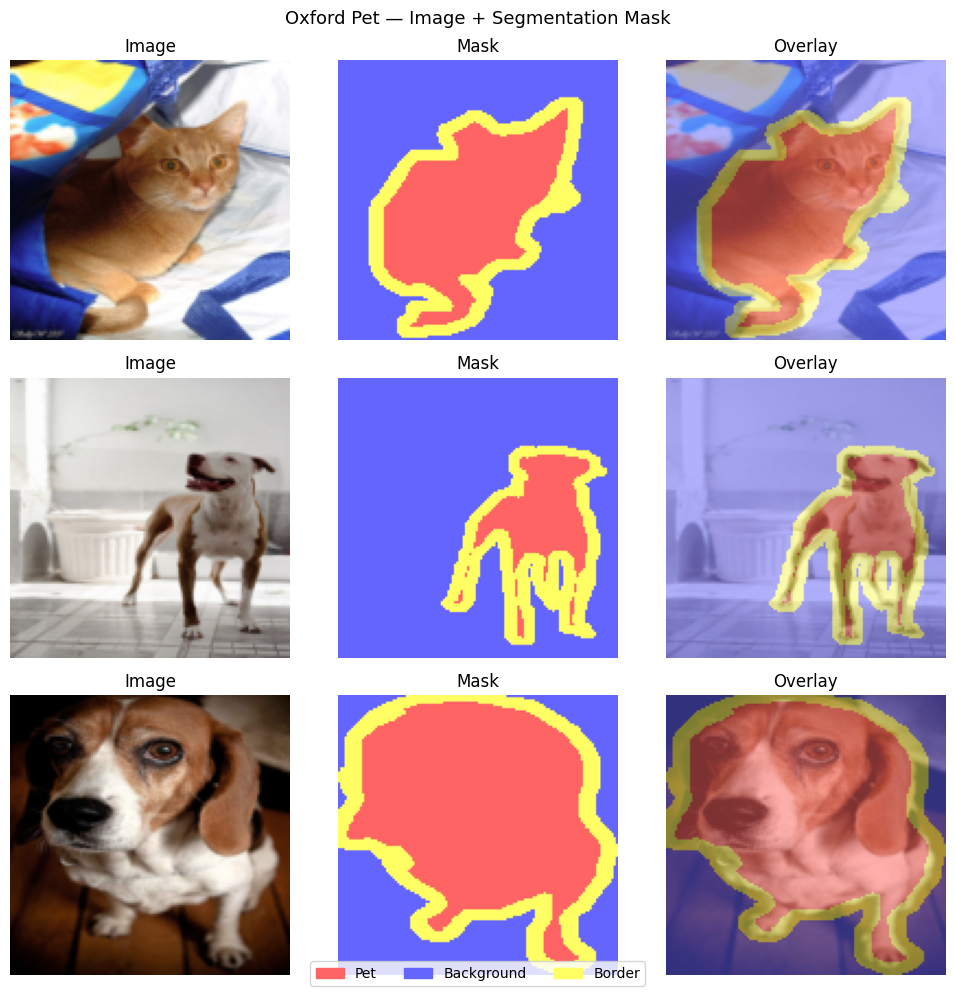

In [2]:
from torchvision.datasets import OxfordIIITPet

os.makedirs('./data', exist_ok=True)
IMG_SIZE = 128

train_raw = OxfordIIITPet('./data', split='trainval', target_types='segmentation', download=True)
test_raw  = OxfordIIITPet('./data', split='test',     target_types='segmentation', download=True)
print(f'Train: {len(train_raw)} | Test: {len(test_raw)}')

class PetSegDataset(Dataset):
    def __init__(self, base, size=128):
        self.ds = base
        self.img_tf  = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        self.mask_tf = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.PILToTensor(),
        ])
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        img, mask = self.ds[idx]
        img  = self.img_tf(img)
        mask = (self.mask_tf(mask).squeeze(0).long() - 1).clamp(0, 2)
        return img, mask

train_data   = PetSegDataset(train_raw, IMG_SIZE)
test_data    = PetSegDataset(test_raw,  IMG_SIZE)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=16, shuffle=False, num_workers=2)

# Visualize samples
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
CLASS_COLORS = np.array([[255,100,100],[100,100,255],[255,255,100]], dtype=np.uint8)
CLASS_NAMES  = ['Pet', 'Background', 'Border']

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    img, mask = train_data[i*100]
    img_d  = torch.clamp(img * std + mean, 0, 1).permute(1,2,0).numpy()
    mask_d = CLASS_COLORS[mask.numpy()]
    axes[i][0].imshow(img_d);  axes[i][0].set_title('Image');   axes[i][0].axis('off')
    axes[i][1].imshow(mask_d); axes[i][1].set_title('Mask');    axes[i][1].axis('off')
    axes[i][2].imshow(img_d);  axes[i][2].imshow(mask_d, alpha=0.5)
    axes[i][2].set_title('Overlay'); axes[i][2].axis('off')
patches = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[i]/255) for i in range(3)]
fig.legend(patches, CLASS_NAMES, loc='lower center', ncol=3)
plt.suptitle('Oxford Pet — Image + Segmentation Mask', fontsize=13)
plt.tight_layout(); plt.show()

In [3]:
class DoubleConv(nn.Module):
    """Two consecutive Conv2d -> BN -> ReLU blocks. The core building block of U-Net."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),  # same-padding keeps spatial size
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, n_classes=3, features=[64, 128, 256, 512]):
        super().__init__()

        # ── Encoder (contracting path) ────────────────────────────────────────
        # Each stage: DoubleConv doubles channels, MaxPool halves spatial size
        # features = [64, 128, 256, 512]  →  4 encoder stages
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))   # e.g. 3→64, 64→128, ...
            self.pools.append(nn.MaxPool2d(2))         # /2 spatial size
            ch = f

        # ── Bottleneck ────────────────────────────────────────────────────────
        # Deepest point: highest channels (512→1024), smallest spatial size
        # No skip connection here — pure semantic compression
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)  # 512→1024

        # ── Decoder (expanding path) ──────────────────────────────────────────
        # Each stage: up-conv doubles spatial size, then concat skip, then DoubleConv
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = features[-1] * 2   # start from bottleneck output (1024)
        for f in reversed(features):   # 512, 256, 128, 64
            self.upconvs.append(
                nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2)  # 2x upsample
            )
            self.decoders.append(
                DoubleConv(f * 2, f)   # f*2 because we concat skip (f) + upconv output (f)
            )
            ch = f

        # ── Output head ───────────────────────────────────────────────────────
        # 1x1 conv maps final feature map to per-pixel class scores
        self.output = nn.Conv2d(features[0], n_classes, kernel_size=1)  # 64→n_classes

    def forward(self, x):
        # ── Encoder: save skip connections at each stage ──────────────────────
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)          # DoubleConv: extract features at this resolution
            skips.append(x)     # save for skip connection to the matching decoder stage
            x = pool(x)         # halve spatial size before next stage

        # ── Bottleneck ────────────────────────────────────────────────────────
        x = self.bottleneck(x)

        # ── Decoder: upsample + skip connection + DoubleConv ─────────────────
        for upconv, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = upconv(x)       # 2x upsample (ConvTranspose2d)

            # Handle size mismatch due to odd input dimensions
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])

            # Skip connection: concat encoder features with decoder features
            # skip carries fine spatial detail (edges, boundaries) from the encoder
            # x    carries semantic context (what object) from the bottleneck
            x = torch.cat([skip, x], dim=1)   # channels: f + f = f*2

            x = dec(x)          # DoubleConv: fuse skip + upsampled features

        # ── Output ────────────────────────────────────────────────────────────
        return self.output(x)   # (N, n_classes, H, W) — same spatial size as input


model = UNet().to(device)
dummy = torch.randn(2, 3, 128, 128).to(device)
out   = model(dummy)
print(f'Input:  {dummy.shape}')
print(f'Output: {out.shape}  <- same H x W as input')
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')


Input:  torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])  <- same H x W as input
Params: 31,037,763


In [4]:
import torchvision.models as models

class UNetResNet18(nn.Module):
    """U-Net with pretrained ResNet-18 encoder. Decoder restores full input resolution.
    
    ResNet-18 on 128x128 input:
      stem_conv (stride=2) → 64x64   [s0, skip]
      stem_pool (stride=2) → 32x32
      layer1               → 32x32   [s1, skip]
      layer2 (stride=2)    → 16x16   [s2, skip]
      layer3 (stride=2)    → 8x8     [s3, skip]
      layer4 (stride=2)    → 4x4     [s4, skip]
    Decoder: 4→8→16→32→64→128 (5 upsamples)
    """

    def __init__(self, n_classes=3, pretrained=True):
        super().__init__()

        weights = 'IMAGENET1K_V1' if pretrained else None
        resnet  = models.resnet18(weights=weights)

        # Stem split into 2 parts to get skip at H/2
        self.stem_conv = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # →H/2, 64ch
        self.stem_pool = resnet.maxpool                                          # →H/4

        self.enc1 = resnet.layer1   # →H/4,  64ch  (no downsample in layer1)
        self.enc2 = resnet.layer2   # →H/8,  128ch
        self.enc3 = resnet.layer3   # →H/16, 256ch
        self.enc4 = resnet.layer4   # →H/32, 512ch

        self.bottleneck = DoubleConv(512, 1024)

        # Decoder: 5 upsamples to go from H/32 back to H
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(512 + 512, 512)   # H/32 → H/16, concat s4

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(256 + 256, 256)   # H/16 → H/8,  concat s3

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(128 + 128, 128)   # H/8  → H/4,  concat s2

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(64 + 64, 64)      # H/4  → H/2,  concat s1

        self.up0  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec0 = DoubleConv(32 + 64, 32)      # H/2  → H,    concat s0 (stem_conv)

        self.output = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        s0 = self.stem_conv(x)   # H/2, 64ch  ← skip for dec0
        sp = self.stem_pool(s0)  # H/4
        s1 = self.enc1(sp)       # H/4, 64ch  ← skip for dec1
        s2 = self.enc2(s1)       # H/8, 128ch ← skip for dec2
        s3 = self.enc3(s2)       # H/16,256ch ← skip for dec3
        s4 = self.enc4(s3)       # H/32,512ch ← skip for dec4

        x = self.bottleneck(s4)  # H/32, 1024ch

        x = self.up4(x);  x = self._cat(x, s4);  x = self.dec4(x)  # H/16
        x = self.up3(x);  x = self._cat(x, s3);  x = self.dec3(x)  # H/8
        x = self.up2(x);  x = self._cat(x, s2);  x = self.dec2(x)  # H/4
        x = self.up1(x);  x = self._cat(x, s1);  x = self.dec1(x)  # H/2
        x = self.up0(x);  x = self._cat(x, s0);  x = self.dec0(x)  # H

        return self.output(x)   # (N, n_classes, H, W)

    def _cat(self, x, skip):
        # x is the upsampled decoder feature — always larger or equal
        # skip may be slightly smaller due to odd dimensions → upsample skip to match x
        if x.shape[2:] != skip.shape[2:]:
            skip = F.interpolate(skip, size=x.shape[2:])
        return torch.cat([skip, x], dim=1)


# Sanity check
resnet_model = UNetResNet18(n_classes=3, pretrained=True).to(device)
dummy = torch.randn(2, 3, 128, 128).to(device)
out   = resnet_model(dummy)
print(f'Input:  {dummy.shape}')
print(f'Output: {out.shape}')
assert out.shape[-2:] == dummy.shape[-2:], f"Size mismatch! {out.shape} vs {dummy.shape}"
print(f'Output size matches input — OK')
print(f'Params: {sum(p.numel() for p in resnet_model.parameters()):,}')


Input:  torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])
Output size matches input — OK
Params: 37,572,099


In [5]:
class UNetResNet18NoSkip(nn.Module):
    """U-Net with pretrained ResNet-18 encoder but NO skip connections (ablation).
    
    Identical encoder to UNetResNet18. The decoder upsamples purely from the
    bottleneck — no encoder feature maps are concatenated. This lets us measure
    exactly how much skip connections contribute to segmentation quality.
    """

    def __init__(self, n_classes=3, pretrained=True):
        super().__init__()

        weights = 'IMAGENET1K_V1' if pretrained else None
        resnet  = models.resnet18(weights=weights)

        # Encoder — same as UNetResNet18
        self.stem_conv = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.stem_pool = resnet.maxpool
        self.enc1 = resnet.layer1
        self.enc2 = resnet.layer2
        self.enc3 = resnet.layer3
        self.enc4 = resnet.layer4

        self.bottleneck = DoubleConv(512, 1024)

        # Decoder — NO skip connections: upconv input/output channels differ
        # because we never concatenate encoder features
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(512, 512)    # 512 only (no concat)

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(256, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(128, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(64, 64)

        self.up0  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec0 = DoubleConv(32, 32)

        self.output = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder (run forward but discard skip connections)
        x = self.stem_conv(x)
        x = self.stem_pool(x)
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)

        x = self.bottleneck(x)

        # Decoder — upsample only, no skip concat
        x = self.up4(x);  x = self.dec4(x)
        x = self.up3(x);  x = self.dec3(x)
        x = self.up2(x);  x = self.dec2(x)
        x = self.up1(x);  x = self.dec1(x)
        x = self.up0(x);  x = self.dec0(x)

        return self.output(x)


# Sanity check
no_skip_model = UNetResNet18NoSkip(n_classes=3, pretrained=True).to(device)
dummy = torch.randn(2, 3, 128, 128).to(device)
out   = no_skip_model(dummy)
print(f'Input:  {dummy.shape}')
print(f'Output: {out.shape}')
assert out.shape[-2:] == dummy.shape[-2:], f"Size mismatch! {out.shape} vs {dummy.shape}"
print('Output size matches input — OK')
print(f'Params: {sum(p.numel() for p in no_skip_model.parameters()):,}')


Input:  torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])
Output size matches input — OK
Params: 34,420,227


In [11]:
# Train both models ──────────────────

MODEL_FLAG = 'unet_resnet18_no_skip'         
DATASET    = 'oxford_pet'
EPOCHS     = 20

def build_model(flag, n_classes=3):
    if flag == 'unet_resnet18':
        return UNetResNet18(n_classes=n_classes, pretrained=True)
    elif flag == 'unet_resnet18_no_skip':
        return UNetResNet18NoSkip(n_classes=n_classes, pretrained=True)
    else:
        raise ValueError(f"Unknown model flag: {flag}")

model = build_model(MODEL_FLAG).to(device)
print(f'Model:   {MODEL_FLAG}')
print(f'Dataset: {DATASET}')
print(f'Epochs:  {EPOCHS}')
print(f'Params:  {sum(p.numel() for p in model.parameters()):,}')

from tqdm import tqdm

def compute_iou(pred, target, n_classes=3):
    pred = pred.argmax(dim=1)
    ious = []
    for cls in range(n_classes):
        inter = ((pred==cls) & (target==cls)).sum().float()
        union = ((pred==cls) | (target==cls)).sum().float()
        if union > 0: ious.append((inter/union).item())
    return np.mean(ious) if ious else 0.0


Model:   unet_resnet18_no_skip
Dataset: oxford_pet
Epochs:  20
Params:  34,420,227


In [12]:
import time

EPOCHS    = 20
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

save_name = f'{MODEL_FLAG}_pet.pt'

train_losses, val_ious, epoch_times = [], [], []

for epoch in range(EPOCHS):
    t0 = time.time()
    model.train()
    ep_loss = []
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        imgs, masks = imgs.to(device), masks.to(device)
        loss = criterion(model(imgs), masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_loss.append(loss.item())

    model.eval()
    ep_iou = []
    with torch.no_grad():
        for imgs, masks in test_loader:
            ep_iou.append(compute_iou(model(imgs.to(device)), masks.to(device)))

    scheduler.step()
    elapsed = time.time() - t0

    train_losses.append(np.mean(ep_loss))
    val_ious.append(np.mean(ep_iou))
    epoch_times.append(elapsed)

    print(f'Epoch {epoch+1:02d} | Loss: {train_losses[-1]:.4f} | mIoU: {val_ious[-1]:.4f} | Time: {elapsed:.1f}s')

torch.save(model.state_dict(), save_name)
print(f'\nSaved → {save_name}')
print(f'Best Val mIoU : {max(val_ious):.4f}')
print(f'Avg Time/epoch: {np.mean(epoch_times):.1f}s')


Epoch 1/20: 100%|██████████| 230/230 [00:10<00:00, 22.51it/s]


Epoch 01 | Loss: 0.5741 | mIoU: 0.4302 | Time: 20.0s


Epoch 2/20: 100%|██████████| 230/230 [00:11<00:00, 20.34it/s]


Epoch 02 | Loss: 0.4578 | mIoU: 0.5316 | Time: 21.1s


Epoch 3/20: 100%|██████████| 230/230 [00:10<00:00, 22.62it/s]


...

Epoch 18 | Loss: 0.1439 | mIoU: 0.6881 | Time: 20.0s


Epoch 19/20: 100%|██████████| 230/230 [00:10<00:00, 21.98it/s]


Epoch 19 | Loss: 0.1416 | mIoU: 0.6823 | Time: 20.0s


Epoch 20/20: 100%|██████████| 230/230 [00:10<00:00, 22.47it/s]


Epoch 20 | Loss: 0.1397 | mIoU: 0.6880 | Time: 19.6s

Saved → unet_resnet18_no_skip_pet.pt
Best Val mIoU : 0.6881
Avg Time/epoch: 20.1s


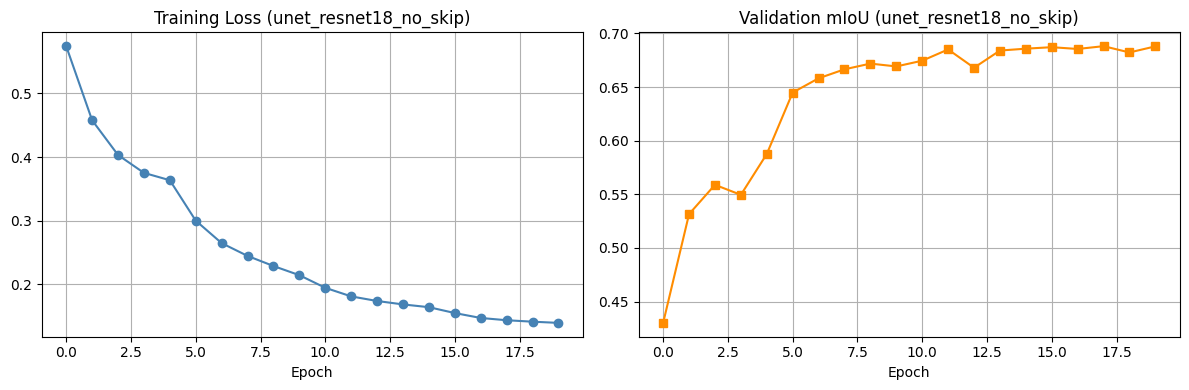

Best mIoU: 0.6881


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, marker='o', color='steelblue')
axes[0].set_title(f'Training Loss ({MODEL_FLAG})'); axes[0].set_xlabel('Epoch'); axes[0].grid(True)
axes[1].plot(val_ious, marker='s', color='darkorange')
axes[1].set_title(f'Validation mIoU ({MODEL_FLAG})'); axes[1].set_xlabel('Epoch'); axes[1].grid(True)
plt.tight_layout(); plt.show()
print(f'Best mIoU: {max(val_ious):.4f}')


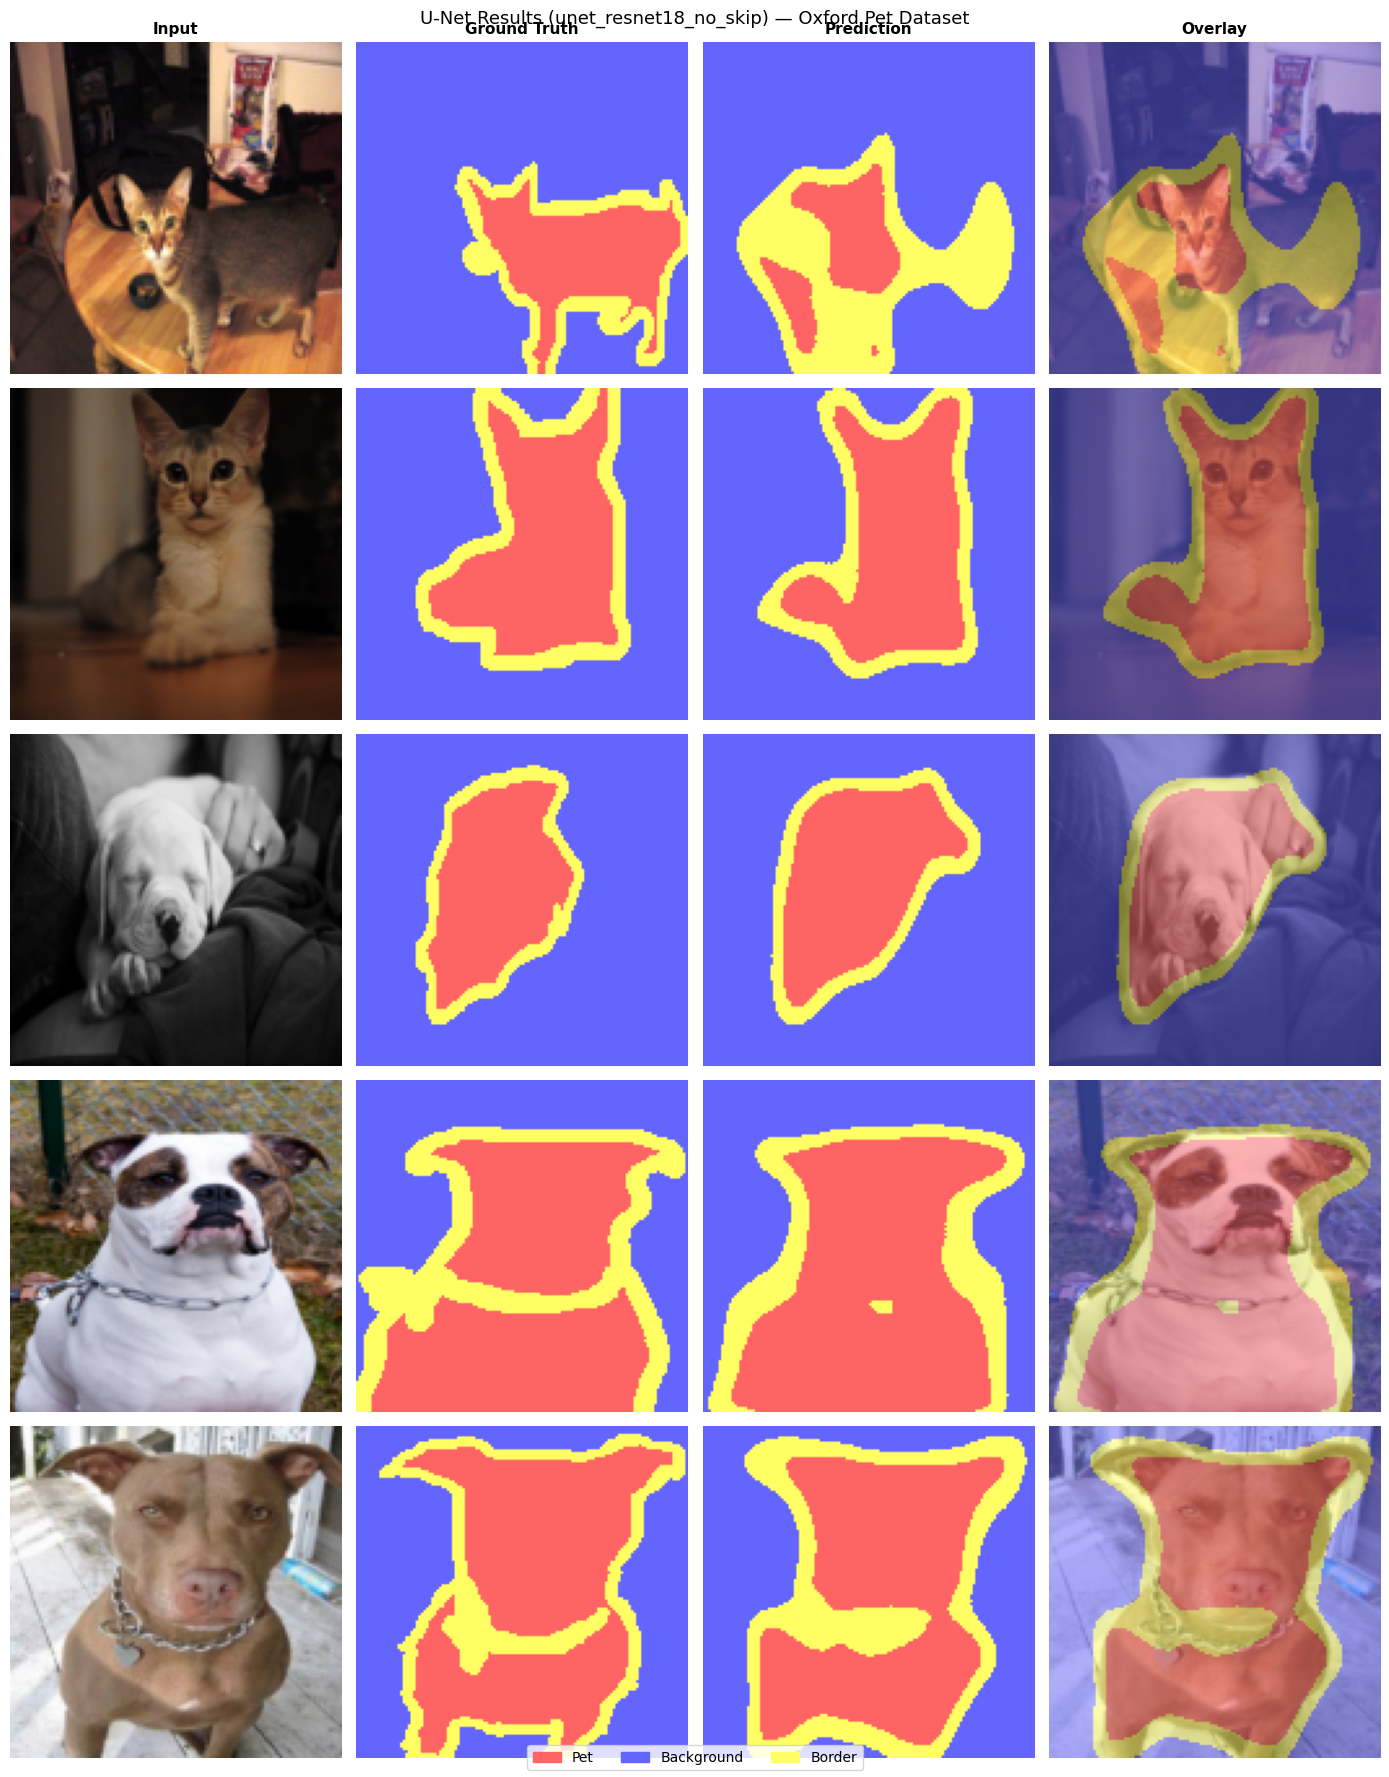

In [14]:
model.load_state_dict(torch.load(save_name, map_location=device))
model.eval()

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
CLASS_COLORS = np.array([[255,100,100],[100,100,255],[255,255,100]], dtype=np.uint8)
CLASS_NAMES  = ['Pet', 'Background', 'Border']

fig, axes = plt.subplots(5, 4, figsize=(14, 18))
for ax, t in zip(axes[0], ['Input','Ground Truth','Prediction','Overlay']):
    ax.set_title(t, fontsize=11, fontweight='bold')

for row in range(5):
    img, mask = test_data[row*50]
    with torch.no_grad():
        pred_mask = model(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()
    img_d  = torch.clamp(img * std + mean, 0, 1).permute(1,2,0).numpy()
    axes[row][0].imshow(img_d)
    axes[row][1].imshow(CLASS_COLORS[mask.numpy()])
    axes[row][2].imshow(CLASS_COLORS[pred_mask])
    axes[row][3].imshow(img_d); axes[row][3].imshow(CLASS_COLORS[pred_mask], alpha=0.5)
    for ax in axes[row]: ax.axis('off')

patches_leg = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[i]/255) for i in range(3)]
fig.legend(patches_leg, CLASS_NAMES, loc='lower center', ncol=3)
plt.suptitle(f'U-Net Results ({MODEL_FLAG}) — Oxford Pet Dataset', fontsize=13)
plt.tight_layout(); plt.show()


In [15]:
# ── Load both trained models ─────────────────────────────────────────────────
model_with    = UNetResNet18(n_classes=3, pretrained=False).to(device)
model_no_skip = UNetResNet18NoSkip(n_classes=3, pretrained=False).to(device)

model_with.load_state_dict(torch.load('unet_resnet18_pet.pt', map_location=device))
model_no_skip.load_state_dict(torch.load('unet_resnet18_no_skip_pet.pt', map_location=device))

def eval_miou(m, loader, n_classes=3):
    m.eval()
    ious = []
    with torch.no_grad():
        for imgs, masks in loader:
            ious.append(compute_iou(m(imgs.to(device)), masks.to(device)))
    return np.mean(ious)

miou_with    = eval_miou(model_with,    test_loader)
miou_no_skip = eval_miou(model_no_skip, test_loader)

print("=" * 55)
print(f"{'Model':<30} {'Skip':^6} {'Val mIoU':>8}")
print("-" * 55)
print(f"{'unet_resnet18':<30} {'Yes':^6} {miou_with:>8.4f}")
print(f"{'unet_resnet18_no_skip':<30} {'No':^6} {miou_no_skip:>8.4f}")
print("=" * 55)
print(f"\nDelta mIoU (skip - no_skip): {miou_with - miou_no_skip:+.4f}")


Model                           Skip  Val mIoU
-------------------------------------------------------
unet_resnet18                   Yes     0.7539
unet_resnet18_no_skip            No     0.6880

Delta mIoU (skip - no_skip): +0.0660


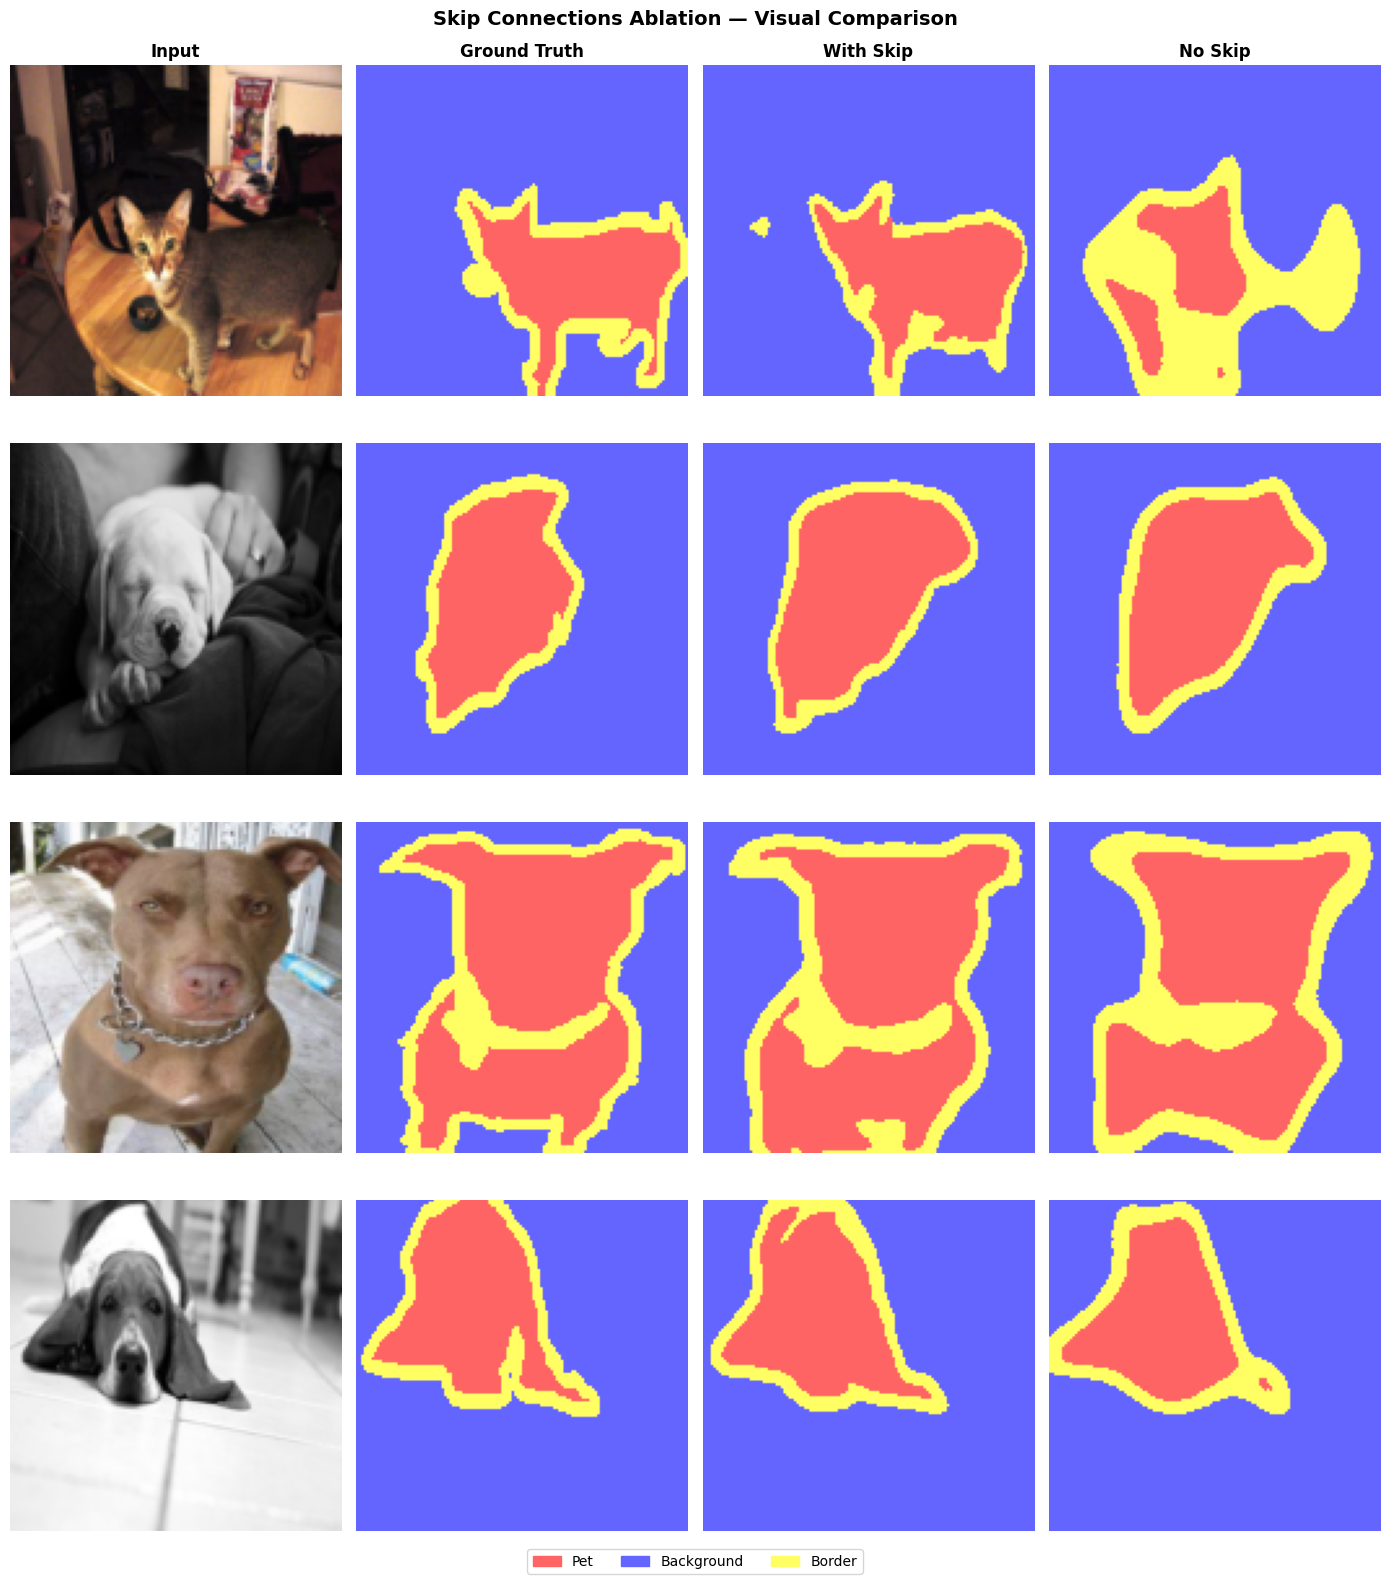

In [16]:
# ── Side-by-side prediction comparison ───────────────────────────────────────
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
CLASS_COLORS = np.array([[255,100,100],[100,100,255],[255,255,100]], dtype=np.uint8)
CLASS_NAMES  = ['Pet', 'Background', 'Border']

n_samples = 4
fig, axes = plt.subplots(n_samples, 4, figsize=(14, 4*n_samples))
col_titles = ['Input', 'Ground Truth', 'With Skip', 'No Skip']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=12, fontweight='bold')

for row in range(n_samples):
    img, mask = test_data[row * 100]
    img_d = torch.clamp(img * std + mean, 0, 1).permute(1,2,0).numpy()

    with torch.no_grad():
        pred_with    = model_with(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()
        pred_no_skip = model_no_skip(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()

    axes[row][0].imshow(img_d)
    axes[row][1].imshow(CLASS_COLORS[mask.numpy()])
    axes[row][2].imshow(CLASS_COLORS[pred_with])
    axes[row][3].imshow(CLASS_COLORS[pred_no_skip])
    for ax in axes[row]: ax.axis('off')

patches_leg = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[i]/255) for i in range(3)]
fig.legend(patches_leg, CLASS_NAMES, loc='lower center', ncol=3)
plt.suptitle('Skip Connections Ablation — Visual Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Discussion: 

1. Why do skip connections help segmentation more than classification?

> Answer: Segmentation requires knowing both *what* an object is and *exactly where* its pixel boundaries are. Skip connections carry high-resolution spatial detail (edges, textures) from shallow encoder layers directly into the decoder, allowing it to recover fine boundary information that is lost during downsampling. Classification only needs a global "what is in this image," for which a compact bottleneck feature vector is sufficient, so skip connections add much less value there.

---

2. Which skip connection level do you think hurts the most when removed — the first (64ch, highest resolution) or the last (512ch, lowest resolution)? Why?



> Answer: The **first** skip connection (64ch, highest resolution) likely hurts the most. It carries the finest spatial detail — exact pixel-level edge maps at near-input resolution — which is the hardest information to reconstruct from a bottleneck. The last skip (512ch, 4×4) provides high-level semantic features at very coarse resolution; that semantic information is already well-represented in the bottleneck, so losing it matters less to the final segmentation quality.